In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import emoji


In [2]:
data = pd.read_csv('../data/geo-reviews-dataset-2023.csv')

In [3]:
data.head()

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


# EDA

In [4]:
data.describe()

,rating
count,500000.00000
mean,4.48160
std,1.14625
min,0.00000
25%,5.00000
50%,5.00000
75%,5.00000
max,5.00000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   address  500000 non-null  object 
 1   name_ru  499030 non-null  object 
 2   rating   500000 non-null  float64
 3   rubrics  500000 non-null  object 
 4   text     500000 non-null  object 
dtypes: float64(1), object(4)
memory usage: 19.1+ MB


В датасете нет пропусков и все признаки имеют нужный тип данных.

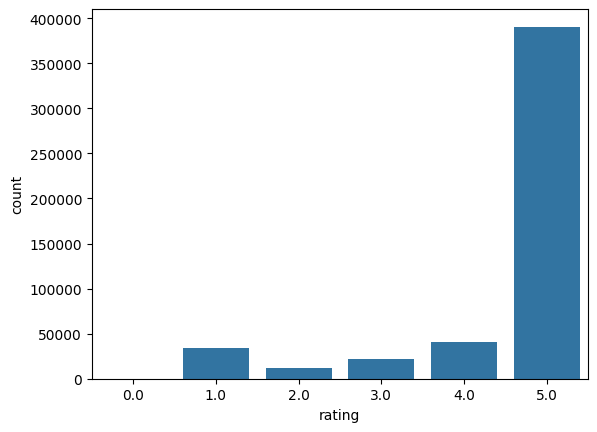

rating
5.0    390515
4.0     41160
1.0     34351
3.0     21686
2.0     12088
0.0       200
Name: count, dtype: int64

In [6]:
sns.countplot(x='rating', data=data)
plt.show()
data.rating.value_counts()

Присуствует сильный дисбаланс классов. В дальнейшем это надо учесть. 

In [7]:
data['num_chars'] = data['text'].str.len()
data['num_words'] = data['text'].str.split().apply(len)

print(data[['num_chars', 'num_words']].describe())


           num_chars      num_words
count  500000.000000  500000.000000
mean      304.233766      43.738286
std       292.550114      44.533202
min         3.000000       1.000000
25%       146.000000      20.000000
50%       216.000000      30.000000
75%       366.000000      52.000000
max     20163.000000    2918.000000


В целом отзывы имеют длину примерно в 40-50 слов

In [8]:
data.groupby(['rating'])['num_chars'].mean()

rating
0.0    255.835000
1.0    538.587028
2.0    513.546741
3.0    429.788158
4.0    338.556438
5.0    266.575141
Name: num_chars, dtype: float64

In [9]:
data.groupby(['rating'])['num_words'].mean()

rating
0.0    36.900000
1.0    82.676516
2.0    78.553276
3.0    64.978373
4.0    49.821234
5.0    37.418350
Name: num_words, dtype: float64

Можно заметить, что негативные отзывы заметно длинее положительных

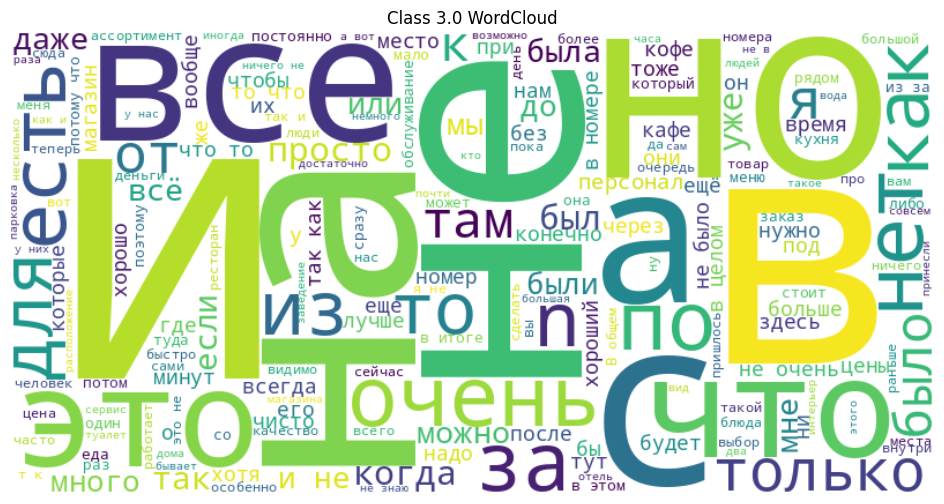

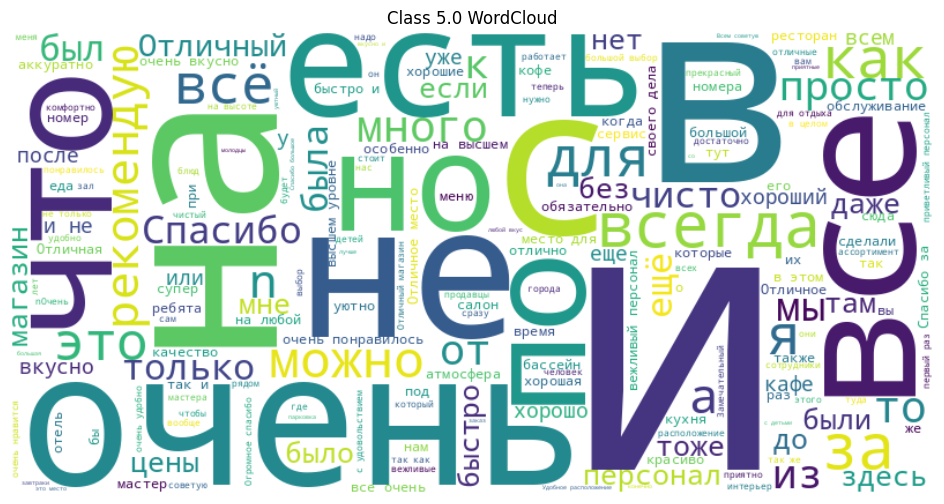

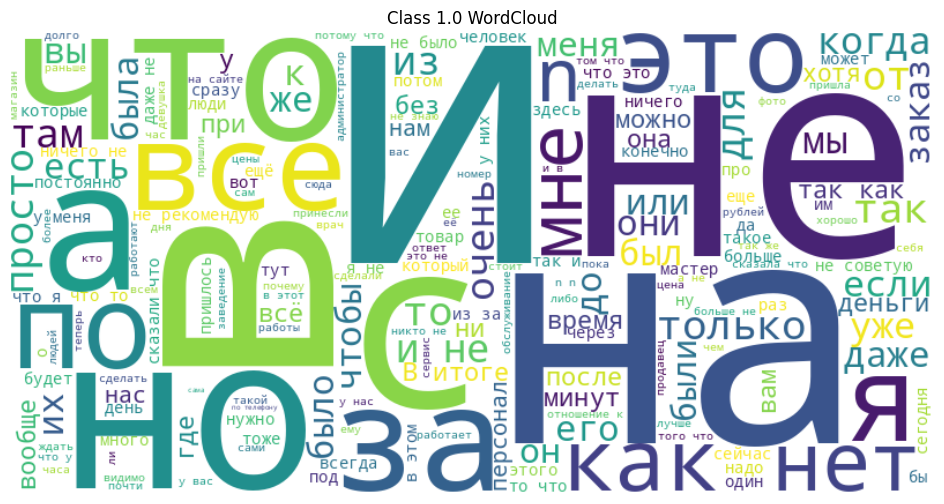

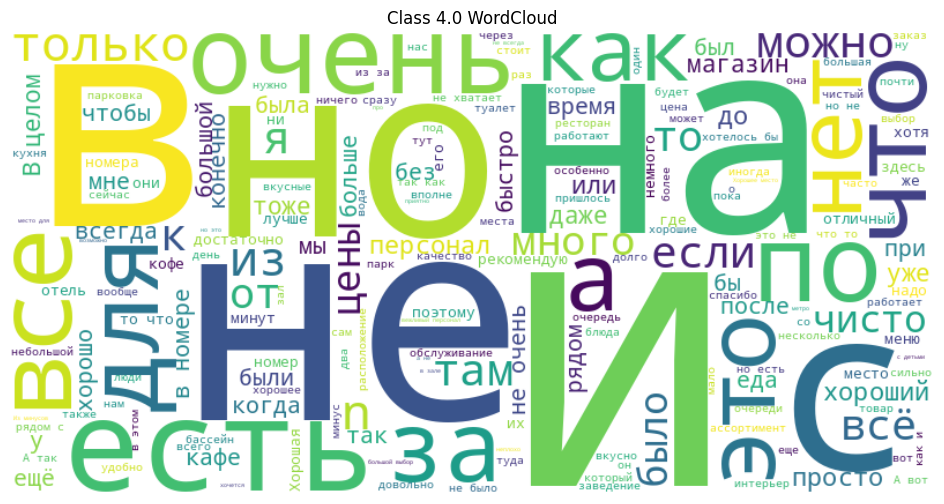

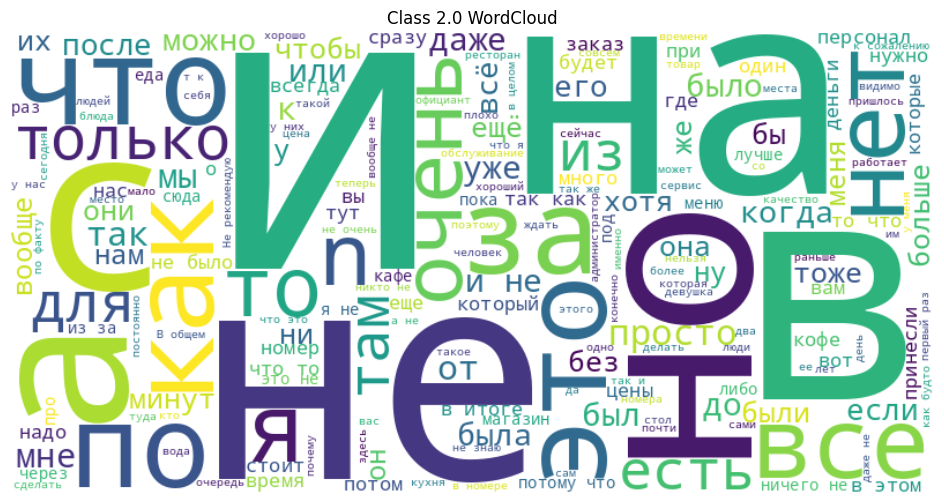

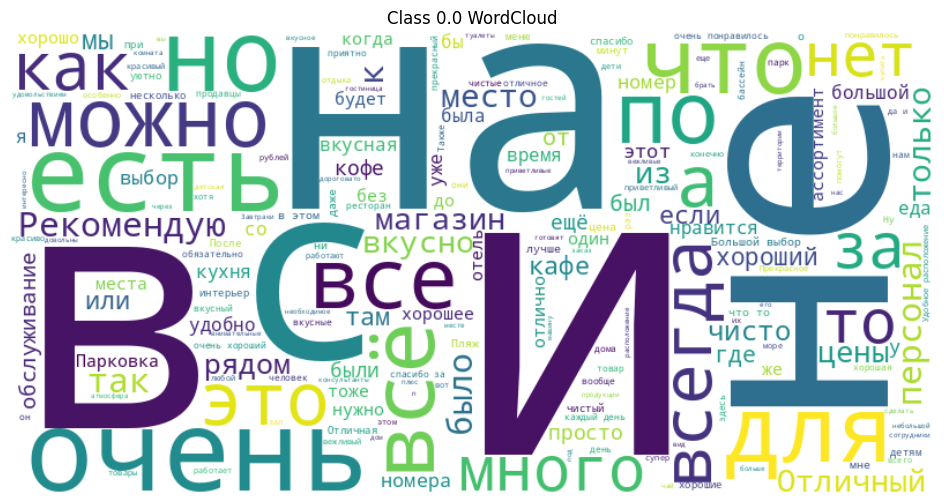

In [11]:

classes = data['rating'].unique()


sample_size = 2000 

for cls in classes:
    # выбираем случайную подвыборку по классу
    df_sample = data[data['rating'] == cls].sample(
        n=min(sample_size, len(data[data['rating'] == cls])),
        random_state=42
    )
    
   
    text = " ".join(df_sample['text'])
    

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Class {cls} WordCloud')
    plt.show()


Можно заметить: 
- много стоп слов
- В положительных отзывах слово "НЕ" имеет меньший вес
- В негативных отзывах люди часто упоминают слова "деньги", "цена", в то время как у положительных отзывов много положительных слов и про финансы не упоминают
- Часто встречается слово персонал или сервис 

In [20]:
def count_emojis(text):
    if not isinstance(text, str):
        text = str(text)
    
    return sum(1 for c in text if c in emoji.EMOJI_DATA)

data['num_emojis'] = data['text'].apply(count_emojis)

In [22]:
data['num_emojis'].describe()

count    500000.000000
mean          0.276628
std           1.265724
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         193.000000
Name: num_emojis, dtype: float64

In [24]:
textEmoji = data[data['num_emojis'] > 0]

In [25]:
textEmoji

,address,name_ru,rating,rubrics,text,num_chars,num_words,num_emojis
8,"Москва, 4-й Кожевнический переулок, 4",Jinju,5.0,Кафе;Кофейня,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вку...",271,44,1
21,"Москва, улица Кирпичные Выемки, 2, корп. 1",Власть взгляда,5.0,Салон бровей и ресниц,Большое спасибо Миле за такие красивые и объём...,311,43,1
28,"Санкт-Петербург, переулок Матюшенко, 8",Кебаб сити,5.0,Быстрое питание,Удобное расположение👍. Работает круглосуточно...,142,20,1
36,"Республика Дагестан, Махачкала, улица Титова, ...",Фаворит женский клуб,5.0,Фитнес-клуб;Спа-салон;Салон красоты,Чудесное место! Душевные приветливые сотрудник...,273,34,1
39,"Алтайский край, Барнаул, улица 1905 года, 25",Epicenter,5.0,Эпиляция,Очень уютная и стильная по интерьеру студия. П...,160,22,1
...,...,...,...,...,...,...,...,...
499967,"Карачаево-Черкесская Республика, Зеленчукский ...",Steak&Kebab house,3.0,Кафе,"Ну что, была я в этом году в данном заведении....",1360,208,1
499970,"Санкт-Петербург, улица Хлопина, 7, корп. 4",Foxy Nail,5.0,Салон красоты;Ногтевая студия;Салон бровей и р...,Хожу в студию уже более полутора лет и каждый ...,1693,253,11
499972,"Севастополь, проспект Генерала Острякова, 155В",Кочерга,5.0,Кафе;Банкетный зал,"Кафе просто супер, как для праздников так и дл...",145,22,3
499974,"Севастополь, проспект Генерала Острякова, 155В",Кочерга,5.0,Кафе;Банкетный зал,"Шашлык отменный, мясо на любой вкус, детская к...",181,26,1


В тексте есть emoji, надо подумать как их обрабатывать

# Prerprocessing classicalML

В рамках нашей задачи для нас важны только rating и text

In [12]:
dfClassical = data[['text', 'rating']].copy()

В данной задаче для дальнейшей аналитики важнее уметь находить отрицательные отзывы, поэтому превратим задачу в бинарную классификацию: 
- 0 - 3 - отрицательные
- 4 - 5 - положительные

Отрицательные отзывы будут обозначены 1.

In [13]:
dfClassical['setniment'] = dfClassical['rating'].apply(lambda x: 1 if x <= 3 else 0)